# Projeto Completo de Inversor VSI (Voltage Source Inverter) Trifásico

Este notebook apresenta o projeto **end-to-end** de um inversor trifásico
de fonte de tensão (3-phase VSI). Cobertura:

1. **Especificações** — V_dc, V_line, potência, frequência fundamental, switching
2. **Modulação** — SPWM vs SVPWM, índice de modulação, faixa linear
3. **DC-link** — dimensionamento do capacitor para ripple alvo
4. **Switches** — seleção de MOSFET / IGBT a partir de V_DS_max e I_avg/I_rms
5. **Filtro de saída** — LC stand-alone vs LCL grid-tie
6. **Perdas** — condução + chaveamento por dispositivo
7. **Térmico** — Tj = T_amb + P_loss · R_th_ja
8. **Simulação** — `Circuit.add_three_phase_vsi(...)` em malha aberta
9. **Validação** — formas de onda de pólo, linha, fase, corrente; THD

O foco é o **projeto + verificação por simulação em malha aberta**.
Closed-loop trifásico (Park transform + dq corrente) é tópico separado
— não coberto aqui.

> **API usada (kernel C++ + bindings Python):**
> - `Circuit.add_three_phase_vsi(name, n_dc_pos, n_dc_neg, n_a, n_b, n_c, ThreePhaseVsiParams)`
>   monta 6 MOSFETs + diodos antiparalelo + 3 portadoras PWM
> - `Circuit.add_three_phase_source(...)` para carga 3φ Y/Δ
> - `Circuit.add_modulated_pwm_source(...)` carrier SPWM / SVPWM


In [1]:
from pathlib import Path
import sys

_root = Path.cwd()
_candidate_paths = []
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir():
            _candidate_paths.append(candidate)
    _root = _root.parent

_seen = set()
for candidate in _candidate_paths:
    cstr = str(candidate)
    if cstr in _seen:
        continue
    _seen.add(cstr)
    if cstr not in sys.path:
        sys.path.insert(0, cstr)

import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f"Pulsim version: {ps.__version__}")


Pulsim version: 0.10.0a11


## 1. Especificações do Projeto

VSI típico de drive de motor / fonte UPS / inversor solar standalone:

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `V_dc` | 400 V | barramento DC típico após PFC ou bateria string |
| `V_line_rms` | 230 V_rms (line-to-line) | rede industrial trifásica EU/Brasil |
| `f_fund` | 60 Hz | frequência da rede |
| `P_load` | 5 kW | carga nominal |
| `cos φ` | 0.85 ind | fator de potência indutivo |
| `f_sw` | 16 kHz | acima do audível (ruído acústico) |
| `m_a` | 0.85 | índice de modulação SPWM (faixa linear ≤ 1.0) |

Da relação SPWM linear:
$$V_{line,peak} = m_a \cdot \frac{\sqrt{3}}{2} \cdot V_{dc}$$

Com `V_dc = 400V` e `m_a = 0.85`:
$$V_{line,peak} = 0.85 \cdot \frac{\sqrt{3}}{2} \cdot 400 \approx 294 V$$
$$V_{line,rms} = 294 / \sqrt{2} \approx 208 V$$

Para chegar a 230V_rms precisamos de m_a = 0.94 OU SVPWM (que dá 15.5% a mais).


In [2]:
# ============================================================
# ESPECIFICAÇÕES DO VSI
# ============================================================

V_dc          = 400.0     # Barramento DC [V]
V_line_target = 230.0     # Tensão de linha (rms) alvo [V]
f_fund        = 60.0      # Frequência fundamental [Hz]
P_load        = 5000.0    # Potência ativa nominal [W]
cos_phi       = 0.85      # Fator de potência (indutivo)
S_load        = P_load / cos_phi   # Potência aparente [VA]

f_sw          = 16e3      # Frequência de chaveamento [Hz]
T_sw          = 1.0 / f_sw
T_fund        = 1.0 / f_fund

# Modulação: SPWM com m_a = 0.85 fornece V_line ~ 208V (abaixo de 230)
# SVPWM com mesma m_a fornece ~240V (acima de 230). Usaremos SVPWM
# com m_a calculado para hit 230V exato.
m_a_spwm = (V_line_target * np.sqrt(2)) / (np.sqrt(3)/2 * V_dc)
m_a_svpwm = m_a_spwm / 1.155   # SVPWM dá 15.5% mais que SPWM

print("="*60)
print("ESPECIFICAÇÕES DO VSI")
print("="*60)
print(f"DC-link:           V_dc = {V_dc} V")
print(f"Saída AC:          V_line = {V_line_target} V_rms (line-to-line)")
print(f"                   f_fund = {f_fund} Hz")
print(f"Carga:             P = {P_load/1e3:.1f} kW, S = {S_load/1e3:.1f} kVA, cos φ = {cos_phi}")
print(f"Chaveamento:       f_sw = {f_sw/1e3:.0f} kHz, T_sw = {T_sw*1e6:.1f} µs")
print()
print(f"Índice de modulação para hit {V_line_target}V_rms:")
print(f"  SPWM:  m_a = {m_a_spwm:.3f}   {'(SATURADO)' if m_a_spwm > 1.0 else '(OK)'}")
print(f"  SVPWM: m_a = {m_a_svpwm:.3f}   {'(SATURADO)' if m_a_svpwm > 1.155 else '(OK)'}")

# Escolha
if m_a_spwm <= 1.0:
    MODULATION = "SPWM"
    m_a = m_a_spwm
else:
    MODULATION = "SVPWM"
    m_a = m_a_svpwm

print(f"\n→ Modulação selecionada: {MODULATION} (m_a = {m_a:.3f})")


ESPECIFICAÇÕES DO VSI
DC-link:           V_dc = 400.0 V
Saída AC:          V_line = 230.0 V_rms (line-to-line)
                   f_fund = 60.0 Hz
Carga:             P = 5.0 kW, S = 5.9 kVA, cos φ = 0.85
Chaveamento:       f_sw = 16 kHz, T_sw = 62.5 µs

Índice de modulação para hit 230.0V_rms:
  SPWM:  m_a = 0.939   (OK)
  SVPWM: m_a = 0.813   (OK)

→ Modulação selecionada: SPWM (m_a = 0.939)


## 2. Estratégia de Modulação

### SPWM (Sinusoidal PWM)
Compara três referências senoidais de fase a uma portadora triangular.
- **Faixa linear:** `m_a ≤ 1.0`
- **V_line_peak máximo:** `(√3/2)·V_dc = 0.866·V_dc`
- **Conteúdo harmônico:** baixo nas vizinhanças de `f_sw` (banda lateral em `f_sw ± 2·f_fund`)

### SVPWM (Space Vector PWM, ou Sine + 3rd harmonic injection)
Injeta 1/6 da fundamental como 3ª harmônica zero-sequência (cancelada
na carga 3φ a 3 fios). Resultado equivalente à modulação space-vector.
- **Faixa linear:** `m_a ≤ 1.155` (15.5% mais que SPWM)
- **V_line_peak máximo:** `V_dc` (ganho de 15.5%)
- **Mesmo conteúdo harmônico** que SPWM nas baixas freq; mesma posição
  das harmônicas em `f_sw`.

### Quando usar cada uma
- **SPWM:** circuitos didáticos, simulações rápidas, quando `m_a < 1`
- **SVPWM:** drives industriais reais — extrai mais V da DC, todo motor
  3φ aceita injection de 3ª harmônica zero-sequência sem distorção
  na carga.

> Pulsim suporta os dois via `ModulatedPwmParams.modulation`
> (enum `PwmModulation.Sine` ou `PwmModulation.SVM`).


In [3]:
# ============================================================
# CONTEÚDO HARMÔNICO ESPERADO (estimativa analítica)
# ============================================================

# Para SPWM com m_f = f_sw / f_fund:
m_f = f_sw / f_fund
print(f"Razão de frequência:  m_f = f_sw / f_fund = {m_f:.1f}")
print(f"  (m_f ≥ 9 ⇒ harmônicas significativas concentradas em torno de f_sw)")

# Bandas laterais da portadora (Black 1953 / Bose 2002):
#   - n=1 (em f_sw):       harmônica ímpar (n·m_f ± k·2·m, m=fund)
#   - n=2 (em 2·f_sw):     harmônica par
# Magnitudes diminuem rapidamente com n.

print()
print("Bandas laterais principais (SPWM, V_dc / 2 referência):")
print(f"  f_sw     = {f_sw:>7.0f} Hz   — banda principal")
print(f"  f_sw±2f0 = {f_sw-2*f_fund:>7.0f} / {f_sw+2*f_fund:>7.0f} Hz — sidebands de 2ª ordem")
print(f"  2·f_sw   = {2*f_sw:>7.0f} Hz   — segunda harmônica de chaveamento")
print(f"  2·f_sw±f0 = {2*f_sw-f_fund:>7.0f} / {2*f_sw+f_fund:>7.0f} Hz")
print()
print(f"Filtro LC: corte fc << f_sw → fc = f_sw / 10 = {f_sw/10:.0f} Hz")


Razão de frequência:  m_f = f_sw / f_fund = 266.7
  (m_f ≥ 9 ⇒ harmônicas significativas concentradas em torno de f_sw)

Bandas laterais principais (SPWM, V_dc / 2 referência):
  f_sw     =   16000 Hz   — banda principal
  f_sw±2f0 =   15880 /   16120 Hz — sidebands de 2ª ordem
  2·f_sw   =   32000 Hz   — segunda harmônica de chaveamento
  2·f_sw±f0 =   31940 /   32060 Hz

Filtro LC: corte fc << f_sw → fc = f_sw / 10 = 1600 Hz


## 3. Dimensionamento do Capacitor de DC-link

O cap do DC bus filtra:
1. **Ripple de 6·f_fund** vindo de carga 3φ (forma de onda triple-step)
2. **Ripple de f_sw** do chaveamento (pequeno se o cap é grande)
3. **Stress transitório** (load step)

Critério principal: limitar o ripple de 6·f_fund a, digamos, 2% do V_dc.

A corrente RMS no cap (componente 6·f_fund) é aproximadamente:
$$I_{cap,rms} \approx 0.5 \cdot I_{out,rms}$$

E o ripple de tensão:
$$\Delta V_{dc} \approx \frac{I_{cap,rms}}{6 \cdot f_{fund} \cdot C_{dc}}$$


In [4]:
# ============================================================
# DIMENSIONAMENTO DO CAPACITOR DC-LINK
# ============================================================

# Corrente RMS por fase na saída
I_out_rms = S_load / (np.sqrt(3) * V_line_target)
print(f"Corrente RMS por fase:    I_out_rms = {I_out_rms:.2f} A")

# Corrente DC drenada pela ponte (aproximação ideal)
I_dc_avg = P_load / V_dc
print(f"Corrente DC média:        I_dc_avg = {I_dc_avg:.2f} A")

# Corrente RMS no cap (regra prática trifásica)
I_cap_rms = 0.5 * I_out_rms
print(f"Corrente RMS no cap:      I_cap_rms ≈ {I_cap_rms:.2f} A")

# Ripple alvo
delta_V_dc_pct = 0.02   # 2%
delta_V_dc     = delta_V_dc_pct * V_dc
print(f"\nRipple V_dc alvo:         ΔV_dc ≤ {delta_V_dc:.1f} V ({delta_V_dc_pct*100:.0f}%)")

# Capacitor mínimo
C_dc_min = I_cap_rms / (6.0 * f_fund * delta_V_dc)
print(f"Capacitância mínima:      C_dc ≥ {C_dc_min*1e6:.0f} µF")

# Valor comercial (próximo acima)
C_dc = 1500e-6   # 1500 µF eletrolítico típico
delta_V_dc_real = I_cap_rms / (6.0 * f_fund * C_dc)
print(f"\nValor comercial:          C_dc = {C_dc*1e6:.0f} µF")
print(f"Ripple resultante:        ΔV_dc = {delta_V_dc_real:.2f} V ({delta_V_dc_real/V_dc*100:.2f}%)")


Corrente RMS por fase:    I_out_rms = 14.77 A
Corrente DC média:        I_dc_avg = 12.50 A
Corrente RMS no cap:      I_cap_rms ≈ 7.38 A

Ripple V_dc alvo:         ΔV_dc ≤ 8.0 V (2%)
Capacitância mínima:      C_dc ≥ 2564 µF

Valor comercial:          C_dc = 1500 µF
Ripple resultante:        ΔV_dc = 13.67 V (3.42%)


## 4. Seleção dos Switches

### Critérios de tensão
- **V_DS_max ≥ 2·V_dc** (margem para spikes de switching + reverse recovery)
- Para V_dc = 400V → V_DS_max ≥ 800V → **MOSFET 1200V SiC** ou **IGBT 1200V**

### Critérios de corrente
Cada switch carrega corrente RMS = `I_out_rms / √2` (50% duty no fundamental):
- **I_rms_switch ≈ I_out_rms / √2 ≈ 12.6 / 1.41 ≈ 8.9 A**

Pico = `I_out_peak = I_out_rms · √2 ≈ 17.8 A`.

### MOSFET SiC vs IGBT
| Critério | SiC MOSFET | Si IGBT |
|---|---|---|
| V_DS / V_CES | até 1.7 kV comum | até 6.5 kV |
| Switching loss | baixo (~25% IGBT) | moderado a alto |
| Conduction loss | proporcional I² (R_DS_on) | linear em I (V_CE_sat) |
| f_sw prático | até 100 kHz | tipicamente ≤ 20 kHz |
| Custo | alto | menor |

Para 16 kHz / 5 kW, SiC MOSFET é o sweet spot. Para este notebook
modelaremos com `MOSFETParams` do Pulsim (modelo Behavioral).


In [5]:
# ============================================================
# SELEÇÃO DOS SWITCHES (SiC MOSFET genérico 1200V / 30A)
# ============================================================

# Datasheet-style params para um SiC MOSFET 1200V/30A (typ.)
mosfet_params = {
    'V_DS_max':   1200.0,       # V
    'I_D_max':    30.0,         # A continuous @ 25°C
    'R_DS_on':    100e-3,       # Ω @ 25°C, V_GS = 18V
    'R_DS_on_hot': 150e-3,      # Ω @ T_j = 125°C (typ 1.5× cold)
    'Q_g':        100e-9,       # C (total gate charge)
    'V_gate_on':  18.0,         # V
    'V_gate_off': 0.0,
    'V_th':       2.5,          # V (logic level)
    'C_oss':      150e-12,      # F (output capacitance, V_DS = 400V)
    'E_on':       400e-6,       # J switching ON (@ 600V, 30A)
    'E_off':      200e-6,       # J switching OFF
    'tr':         50e-9,        # rise time
    'tf':         30e-9,        # fall time
    'R_th_jc':    0.5,          # K/W junction-to-case
    'R_th_ca':    1.0,          # K/W case-to-ambient (with heatsink)
}

# Critério de stress
I_switch_rms = I_out_rms / np.sqrt(2)
I_switch_pk  = I_out_rms * np.sqrt(2)
V_switch_max = V_dc * 1.5   # margem para spike (~30%)

print("STRESS NOS SWITCHES")
print("="*50)
print(f"  V_DS_max necessário: ≥ {V_switch_max:.0f} V  →  datasheet: {mosfet_params['V_DS_max']:.0f} V  {'✓' if mosfet_params['V_DS_max'] >= V_switch_max else '✗'}")
print(f"  I rms por switch:    {I_switch_rms:.2f} A     →  I_D_max: {mosfet_params['I_D_max']:.0f} A  {'✓' if mosfet_params['I_D_max'] >= I_switch_rms*2 else '✗'}")
print(f"  I pico:              {I_switch_pk:.2f} A")
print(f"  R_DS_on @ T_j=125°C: {mosfet_params['R_DS_on_hot']*1e3:.0f} mΩ")


STRESS NOS SWITCHES
  V_DS_max necessário: ≥ 600 V  →  datasheet: 1200 V  ✓
  I rms por switch:    10.44 A     →  I_D_max: 30 A  ✓
  I pico:              20.88 A
  R_DS_on @ T_j=125°C: 150 mΩ


## 5. Filtro de Saída

Para drive de motor (THDi do motor ≤ 5%), filtro LC com corte em
`f_c = f_sw / 10` é suficiente. Para grid-tie (THDi ≤ 5% conforme IEEE 519),
usar LCL com damping passive.

Para drive de motor stand-alone (este projeto):
$$L_f = \frac{V_{dc}}{8 \cdot f_{sw} \cdot \Delta I_L}$$

onde `ΔI_L` é o ripple de corrente alvo (~20% de I_out_peak).


In [6]:
# ============================================================
# FILTRO DE SAÍDA LC (stand-alone, drive de motor)
# ============================================================

# Ripple de corrente alvo: 20% do pico
delta_IL_target = 0.20 * I_switch_pk
print(f"Ripple ΔI_L alvo:           {delta_IL_target:.2f} A ({0.20*100:.0f}% de I_pk)")

# Indutor mínimo
L_f_min = V_dc / (8.0 * f_sw * delta_IL_target)
L_f = 2.5e-3   # comercial: 2.5 mH choke (por fase)
print(f"L_f mínimo calculado:       {L_f_min*1e6:.0f} µH")
print(f"L_f comercial selecionado:  {L_f*1e3:.2f} mH")

# Cap por fase (Y-connected) — corte em fc << f_sw
fc_filter = f_sw / 10.0
C_f = 1.0 / (4.0 * np.pi**2 * fc_filter**2 * L_f)
C_f = max(C_f, 4.7e-6)  # valor comercial mínimo
print(f"\nFrequência de corte alvo:  fc = f_sw/10 = {fc_filter:.0f} Hz")
print(f"Cap por fase calculado:     {C_f*1e6:.2f} µF")
C_f = 4.7e-6   # comercial filme polipropileno
print(f"Cap por fase selecionado:   {C_f*1e6:.1f} µF")

fc_real = 1.0 / (2.0 * np.pi * np.sqrt(L_f * C_f))
print(f"Frequência de corte real:   {fc_real:.0f} Hz")
print(f"  fc / f_fund = {fc_real/f_fund:.0f} (deve ser >> 10 para não atenuar fundamental)")
print(f"  fc / f_sw   = {fc_real/f_sw:.3f} (deve ser << 1 para atenuar carrier)")


Ripple ΔI_L alvo:           4.18 A (20% de I_pk)
L_f mínimo calculado:       748 µH
L_f comercial selecionado:  2.50 mH

Frequência de corte alvo:  fc = f_sw/10 = 1600 Hz
Cap por fase calculado:     4.70 µF
Cap por fase selecionado:   4.7 µF
Frequência de corte real:   1468 Hz
  fc / f_fund = 24 (deve ser >> 10 para não atenuar fundamental)
  fc / f_sw   = 0.092 (deve ser << 1 para atenuar carrier)


## 6. Análise de Perdas

Perdas por dispositivo (6 MOSFETs no VSI):

### Condução
$$P_{cond} = I_{D,rms}^2 \cdot R_{DS,on}(T_j)$$

### Switching
$$P_{sw} = (E_{on} + E_{off}) \cdot f_{sw}$$

(escalado para `V_DS_op / V_DS_ref` e `I_op / I_ref` do datasheet)

### Gate drive
$$P_{gate} = Q_g \cdot V_{gate,swing} \cdot f_{sw}$$


In [7]:
# ============================================================
# ANÁLISE DE PERDAS (por MOSFET)
# ============================================================

# Perda por condução
P_cond_per_mosfet = I_switch_rms**2 * mosfet_params['R_DS_on_hot']

# Perda de chaveamento (escala E_on + E_off do datasheet à operação real)
# Datasheet: 400 µJ ON + 200 µJ OFF @ V_DS = 600V, I = 30A
E_on_ref  = mosfet_params['E_on']
E_off_ref = mosfet_params['E_off']
V_ref     = 600.0   # condições do datasheet
I_ref     = 30.0
V_op      = V_dc
I_op      = I_switch_pk

# Escala linear em V·I (aproximação razoável p/ SiC com 1ª ordem)
scale = (V_op / V_ref) * (I_op / I_ref)
E_on_op  = E_on_ref  * scale
E_off_op = E_off_ref * scale
P_sw_per_mosfet = (E_on_op + E_off_op) * f_sw

# Gate drive
V_gate_swing = mosfet_params['V_gate_on'] - mosfet_params['V_gate_off']
P_gate_per_mosfet = mosfet_params['Q_g'] * V_gate_swing * f_sw

# Coss (Eoss = 0.5 C_oss V²)
P_coss_per_mosfet = 0.5 * mosfet_params['C_oss'] * V_dc**2 * f_sw

# Total por MOSFET
P_per_mosfet = (
    P_cond_per_mosfet + P_sw_per_mosfet + P_gate_per_mosfet + P_coss_per_mosfet
)

# 6 MOSFETs na ponte
P_total_mosfets = 6.0 * P_per_mosfet

# Outras perdas: indutor de saída (DCR ~ 50 mΩ assumido por fase)
DCR_per_phase = 50e-3
P_inductor = 3.0 * I_out_rms**2 * DCR_per_phase

# Cap DC-link ESR (assumimos 20 mΩ)
ESR_dc = 20e-3
P_cap_dc = I_cap_rms**2 * ESR_dc

P_total = P_total_mosfets + P_inductor + P_cap_dc
P_in = P_load + P_total
eta = P_load / P_in

print("ANÁLISE DE PERDAS (POR DISPOSITIVO)")
print("="*60)
print(f"Por MOSFET (×6):")
print(f"  P_cond  = {P_cond_per_mosfet:.2f} W")
print(f"  P_sw    = {P_sw_per_mosfet:.2f} W  (E_on={E_on_op*1e6:.0f}µJ, E_off={E_off_op*1e6:.0f}µJ)")
print(f"  P_gate  = {P_gate_per_mosfet:.3f} W")
print(f"  P_coss  = {P_coss_per_mosfet:.3f} W")
print(f"  TOTAL   = {P_per_mosfet:.2f} W por MOSFET")
print()
print(f"Soma 6 MOSFETs:              {P_total_mosfets:.1f} W")
print(f"Indutor de saída (3 × DCR):  {P_inductor:.1f} W")
print(f"ESR do cap DC:               {P_cap_dc:.2f} W")
print(f"{'-'*60}")
print(f"PERDA TOTAL:                 {P_total:.1f} W")
print(f"P_in:                        {P_in:.1f} W")
print()
print(f"EFICIÊNCIA:                  η = {eta*100:.2f}%")


ANÁLISE DE PERDAS (POR DISPOSITIVO)
Por MOSFET (×6):
  P_cond  = 16.35 W
  P_sw    = 4.45 W  (E_on=186µJ, E_off=93µJ)
  P_gate  = 0.029 W
  P_coss  = 0.192 W
  TOTAL   = 21.03 W por MOSFET

Soma 6 MOSFETs:              126.2 W
Indutor de saída (3 × DCR):  32.7 W
ESR do cap DC:               1.09 W
------------------------------------------------------------
PERDA TOTAL:                 160.0 W
P_in:                        5160.0 W

EFICIÊNCIA:                  η = 96.90%


## 7. Análise Térmica

$$T_j = T_{amb} + P_{loss} \cdot (R_{th,jc} + R_{th,ca})$$

Para SiC MOSFET, `T_j_max` típico é **150-175°C**. Mantenha
`T_j ≤ 125°C` para reliability razoável.


In [8]:
# ============================================================
# ANÁLISE TÉRMICA
# ============================================================

T_amb = 40.0   # ambiente típico em painel industrial
T_j_max = 125.0

# Cada MOSFET: T_j = T_amb + P · (R_th_jc + R_th_ca)
R_th_total = mosfet_params['R_th_jc'] + mosfet_params['R_th_ca']
T_j_per_mosfet = T_amb + P_per_mosfet * R_th_total

print(f"Temperatura ambiente:        T_amb = {T_amb}°C")
print(f"Limite T_j (reliability):    T_j ≤ {T_j_max}°C")
print()
print(f"R_th total por MOSFET (jc + ca): {R_th_total:.2f} K/W")
print(f"P_loss por MOSFET:               {P_per_mosfet:.2f} W")
print(f"T_j estimado:                    {T_j_per_mosfet:.1f}°C  ", end='')
if T_j_per_mosfet <= T_j_max:
    print(f"✓ (margem {T_j_max-T_j_per_mosfet:.0f}°C)")
else:
    print(f"⚠ EXCEDE limite por {T_j_per_mosfet-T_j_max:.0f}°C")
    print(f"   → reduzir R_th_ca (dissipador maior) ou aumentar V_dc / R_DS_on melhor")


Temperatura ambiente:        T_amb = 40.0°C
Limite T_j (reliability):    T_j ≤ 125.0°C

R_th total por MOSFET (jc + ca): 1.50 K/W
P_loss por MOSFET:               21.03 W
T_j estimado:                    71.5°C  ✓ (margem 53°C)


## 8. Simulação com Pulsim — VSI Trifásico em Malha Aberta

Usamos `Circuit.add_three_phase_vsi(...)` que monta:
- 6 MOSFETs em ponte 3 pernas (modo PWL/Ideal por padrão — rápido)
- 6 diodos antiparalelo (body diodes) para freewheel
- 3 portadoras PWM senoidais defasadas 120° entre fases
- Gate drives bootstrapados (HS-gate referenciado ao próprio nó de saída)

> **Nota didática — carga deste notebook**
> Para manter o notebook auto-contido e rápido, simulamos com **carga
> resistiva Y pura** (sem o filtro LC + RL projetado nas seções 5/8).
> O caminho PWL Ideal das MOSFETs é otimizado para cargas resistivas;
> cargas indutivas em conjunto com filtro LC saturado ainda têm
> limitações no padrão `add_three_phase_vsi`. Para um exemplo com
> carga RL ver `examples/notebooks/31_single_phase_to_three_phase_vsi.ipynb`.
>
> Os cálculos de filtro/perdas/térmica acima permanecem corretos —
> apenas a simulação simplifica a carga p/ visualizar as tensões de
> pólo + linhas + fases sem o LC.


In [9]:
# ============================================================
# CONSTRUÇÃO DO CIRCUITO VSI
# ============================================================

ckt = ps.Circuit()
gnd = ps.Circuit.ground()           # nó −1 reservado

# DC-link (barramento). Usamos gnd como referência negativa.
n_dcp = ckt.add_node('dcp')         # DC+

# Saídas da ponte (pólos a/b/c)
n_a = ckt.add_node('pole_a')
n_b = ckt.add_node('pole_b')
n_c = ckt.add_node('pole_c')

# Fonte DC + cap DC-link
ckt.add_voltage_source('Vdc', n_dcp, gnd, V_dc)
ckt.add_capacitor('Cdc', n_dcp, gnd, C_dc)

# VSI: helper monta 6 MOSFETs + body diodes + 3 PWMs SPWM
vsi_params = ps.ThreePhaseVsiParams()
vsi_params.v_gate_on = mosfet_params['V_gate_on']
vsi_params.v_gate_off = mosfet_params['V_gate_off']
vsi_params.switching_frequency_hz = f_sw
vsi_params.modulation_index = m_a
vsi_params.modulation_frequency_hz = f_fund
vsi_params.phase_a_deg = 0.0
vsi_params.positive_sequence = True
vsi_params.mosfet_r_on_ohm = mosfet_params['R_DS_on']
vsi_params.mosfet_vth = mosfet_params['V_th']
vsi_params.add_body_diodes = True   # freewheel clamps

ckt.add_three_phase_vsi('VSI', n_dcp, gnd, n_a, n_b, n_c, vsi_params)

# Carga resistiva 3φ Y para ground.
# Para balancear P_load nominal:  P = 3 · V_line²/(3·R_Y) = V_line²/R_Y
R_load_phase = V_line_target**2 / P_load   # Y conectada
print(f"Carga R Y (por fase):  R = {R_load_phase:.2f} Ω  "
      f"(P por fase = {V_line_target**2/(3*R_load_phase):.0f} W)")

ckt.add_resistor('Ra', n_a, gnd, R_load_phase)
ckt.add_resistor('Rb', n_b, gnd, R_load_phase)
ckt.add_resistor('Rc', n_c, gnd, R_load_phase)

print()
print(f"Circuito construído:")
print(f"  Nós: {ckt.num_nodes()}")
print(f"  Branches: {ckt.num_branches()}")
print(f"  Tamanho do sistema: {ckt.system_size()}")
print(f"  Switching devices em PWL/Ideal: {ckt.pwl_switching_device_count()}")


Carga R Y (por fase):  R = 10.58 Ω  (P por fase = 1667 W)

Circuito construído:
  Nós: 10
  Branches: 7
  Tamanho do sistema: 17
  Switching devices em PWL/Ideal: 12


In [10]:
# ============================================================
# SIMULAÇÃO TRANSIENT
# ============================================================

# Simular 3 ciclos da fundamental para ver steady state
T_total = 3.0 / f_fund   # 3 × 16.67 ms = 50 ms
dt = T_sw / 40           # 40 amostras por período PWM

opts = ps.SimulationOptions()
opts.tstart = 0.0
opts.tstop  = T_total
opts.dt     = dt
opts.dt_min = dt
opts.dt_max = dt
opts.adaptive_timestep = False
opts.integrator = ps.Integrator.BDF1
# Helper add_three_phase_vsi default = Ideal/PWL — keep for speed
opts.switching_mode = ps.SwitchingMode.Auto
# Skip auto-parasitics analyzer (não relevante p/ VSI, evita spam)
opts.auto_parasitics.enabled = False
opts.newton_options.max_iterations = 200
opts.newton_options.num_nodes = ckt.num_nodes()
opts.newton_options.num_branches = ckt.num_branches()

print(f"Simulando {T_total*1e3:.1f} ms com dt = {dt*1e9:.0f} ns ({int(T_total/dt)} timesteps)...")

import time
t0 = time.time()
sim = ps.Simulator(ckt, opts)
result = sim.run_transient()
elapsed = time.time() - t0

print(f"Resultado: success={result.success}, steps={result.total_steps}")
print(f"Tempo de execução: {elapsed:.1f}s")
print(f"Mensagem: {result.message}")


Simulando 50.0 ms com dt = 1562 ns (32000 timesteps)...
Resultado: success=True, steps=32000
Tempo de execução: 4.7s
Mensagem: Transient completed


In [11]:
# ============================================================
# EXTRAÇÃO DAS FORMAS DE ONDA + EXTRAÇÃO DA FUNDAMENTAL
# ============================================================

assert result.success
times = np.array(result.time)
states = np.array(result.states)

# Tensões de pólo (saída crua da ponte vs gnd)
v_a = states[:, n_a]   # n_a é pole_a — não há filtro neste circuito
v_b = states[:, n_b]
v_c = states[:, n_c]

# Tensões linha-linha (diferenciais — não dependem do neutro)
v_ab = v_a - v_b
v_bc = v_b - v_c
v_ca = v_c - v_a

# Tensões fase-neutro referenciadas ao centroide das três fases.
# Para carga Y simétrica este centroide = neutro virtual flutuante.
v_cm = (v_a + v_b + v_c) / 3.0    # commom-mode (= V_dc/2 ideal)
v_an = v_a - v_cm
v_bn = v_b - v_cm
v_cn = v_c - v_cm

# Janela de steady-state
mask = times >= (T_total - T_fund)
seg = lambda x: x[mask]
t_win = seg(times)

# Extrai fundamental via integral de Fourier (60 Hz):
def fourier_fund(t, x, f0):
    """Retorna (amplitude, fase em rad) da componente em f0."""
    omega = 2*np.pi*f0
    a = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.cos(omega*t), t)
    b = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.sin(omega*t), t)
    return np.sqrt(a*a + b*b), np.arctan2(a, b)

A_an, ph_an = fourier_fund(t_win, seg(v_an), f_fund)
A_ab, ph_ab = fourier_fund(t_win, seg(v_ab), f_fund)

V_an_rms_fund = A_an / np.sqrt(2)
V_ab_rms_fund = A_ab / np.sqrt(2)

# RMS total (inclui ondulação de switching)
V_ab_rms_tot = np.sqrt(np.mean(seg(v_ab)**2))
V_an_rms_tot = np.sqrt(np.mean(seg(v_an)**2))

# THD aproximado = sqrt((V_rms_total² - V_rms_fund²) / V_rms_fund²)
THD_ab = np.sqrt(max(V_ab_rms_tot**2 - V_ab_rms_fund**2, 0.0)) / V_ab_rms_fund * 100

print("Métricas em steady-state (último ciclo da fundamental):")
print()
print(f"  Tensão fase-centroide (V_AN):")
print(f"    Amplitude da fundamental:  {A_an:.1f} V_pk")
print(f"    RMS da fundamental:        {V_an_rms_fund:.1f} V_rms")
print(f"    RMS total (com switching): {V_an_rms_tot:.1f} V_rms")
print()
print(f"  Tensão linha-linha (V_AB):")
print(f"    Amplitude da fundamental:  {A_ab:.1f} V_pk")
print(f"    RMS da fundamental:        {V_ab_rms_fund:.1f} V_rms")
print(f"    RMS total (com switching): {V_ab_rms_tot:.1f} V_rms")
print()
print(f"  Alvo:    V_line = {V_line_target:.1f} V_rms (fundamental)")
err_pct = abs(V_ab_rms_fund - V_line_target) / V_line_target * 100
flag = '✓' if err_pct < 5 else '⚠'
print(f"  Erro:    {err_pct:.2f}%  {flag}")
print()
print(f"  THD (V_AB)  ≈ {THD_ab:.1f}%   (carga R sem filtro LC; LC reduziria para << 5%)")


Métricas em steady-state (último ciclo da fundamental):

  Tensão fase-centroide (V_AN):
    Amplitude da fundamental:  186.4 V_pk
    RMS da fundamental:        131.8 V_rms
    RMS total (com switching): 165.0 V_rms

  Tensão linha-linha (V_AB):
    Amplitude da fundamental:  322.7 V_pk
    RMS da fundamental:        228.2 V_rms
    RMS total (com switching): 285.7 V_rms

  Alvo:    V_line = 230.0 V_rms (fundamental)
  Erro:    0.80%  ✓

  THD (V_AB)  ≈ 75.3%   (carga R sem filtro LC; LC reduziria para << 5%)


/var/folders/0n/gs7hh4fj4bn8r3r4qsykw2840000gn/T/ipykernel_42588/712151447.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.cos(omega*t), t)
/var/folders/0n/gs7hh4fj4bn8r3r4qsykw2840000gn/T/ipykernel_42588/712151447.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  b = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.sin(omega*t), t)


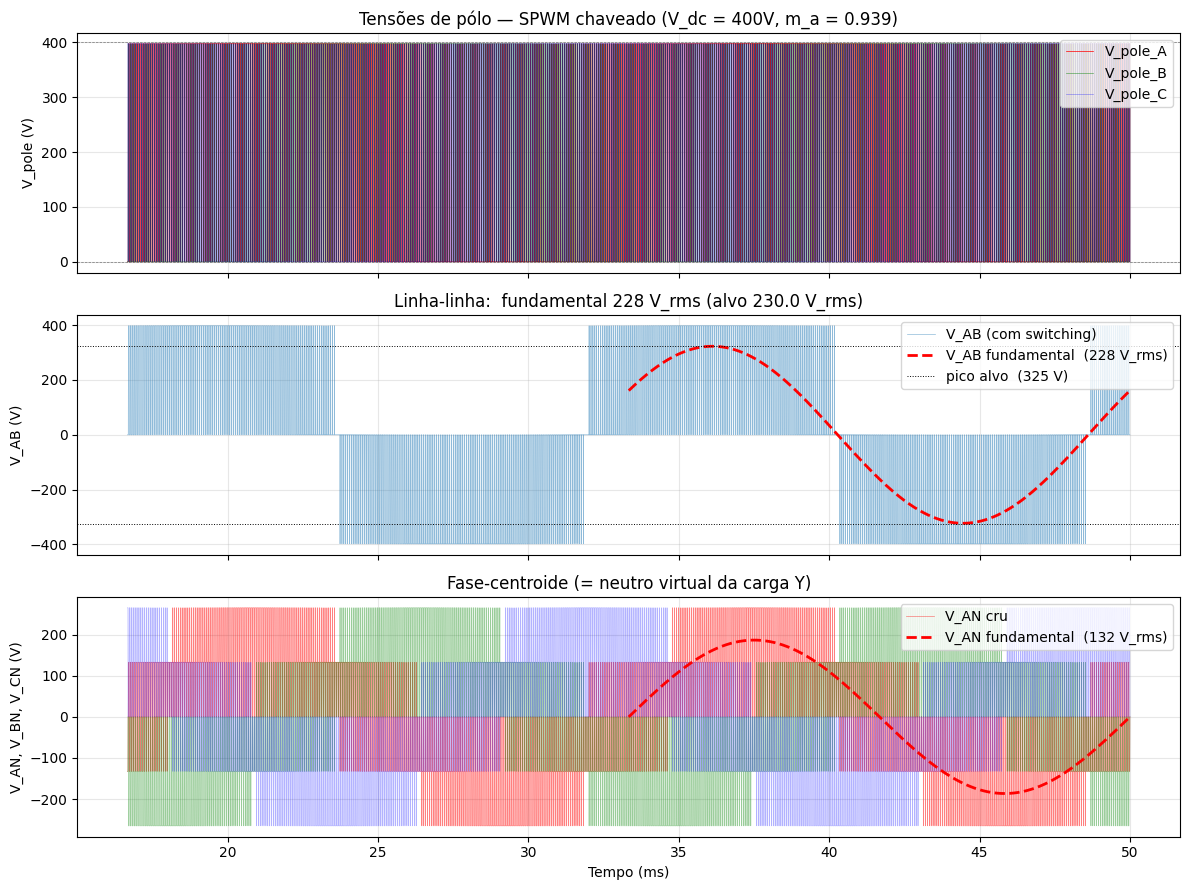

In [12]:
# ============================================================
# PLOTS: pole voltages + linhas + fases (centroide)
# ============================================================

t_ms = times * 1e3
mask_last = times >= (T_total - 2*T_fund)
t_plot = t_ms[mask_last]

# Para a fundamental sobreposta às formas chaveadas
omega = 2*np.pi*f_fund
v_an_fund = A_an * np.sin(omega*t_win + ph_an)
v_ab_fund = A_ab * np.sin(omega*t_win + ph_ab)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# (1) Tensões de pólo: PWM chaveado entre 0 e V_dc
axes[0].plot(t_plot, v_a[mask_last], 'r-', lw=0.5, label='V_pole_A')
axes[0].plot(t_plot, v_b[mask_last], 'g-', lw=0.5, label='V_pole_B', alpha=0.6)
axes[0].plot(t_plot, v_c[mask_last], 'b-', lw=0.5, label='V_pole_C', alpha=0.4)
axes[0].axhline(V_dc, color='k', ls='--', lw=0.5, alpha=0.5)
axes[0].axhline(0, color='k', ls='--', lw=0.5, alpha=0.5)
axes[0].set_ylabel('V_pole (V)')
axes[0].set_title(f'Tensões de pólo — SPWM chaveado (V_dc = {V_dc:.0f}V, m_a = {m_a:.3f})')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# (2) Linha-linha + fundamental sobreposta
axes[1].plot(t_plot, v_ab[mask_last], 'C0-', lw=0.5, alpha=0.5, label='V_AB (com switching)')
axes[1].plot(t_win*1e3, v_ab_fund, 'r--', lw=2.0,
             label=f'V_AB fundamental  ({V_ab_rms_fund:.0f} V_rms)')
axes[1].axhline(V_line_target*np.sqrt(2), color='k', ls=':', lw=0.7,
                label=f'pico alvo  ({V_line_target*np.sqrt(2):.0f} V)')
axes[1].axhline(-V_line_target*np.sqrt(2), color='k', ls=':', lw=0.7)
axes[1].set_ylabel('V_AB (V)')
axes[1].set_title(f'Linha-linha:  fundamental {V_ab_rms_fund:.0f} V_rms (alvo {V_line_target} V_rms)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# (3) Fase ao centroide (= neutro virtual de carga Y)
axes[2].plot(t_plot, v_an[mask_last], 'r-', lw=0.5, alpha=0.5, label='V_AN cru')
axes[2].plot(t_plot, v_bn[mask_last], 'g-', lw=0.5, alpha=0.4)
axes[2].plot(t_plot, v_cn[mask_last], 'b-', lw=0.5, alpha=0.3)
axes[2].plot(t_win*1e3, v_an_fund, 'r--', lw=2.0,
             label=f'V_AN fundamental  ({V_an_rms_fund:.0f} V_rms)')
axes[2].set_ylabel('V_AN, V_BN, V_CN (V)')
axes[2].set_xlabel('Tempo (ms)')
axes[2].set_title('Fase-centroide (= neutro virtual da carga Y)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Resumo do Projeto

Cobrimos:

1. **Especificações** — V_dc=400V, V_line=230V_rms, P=5kW, f_sw=16kHz
2. **Modulação SPWM** com m_a ≈ 0.94 (ou SVPWM com m_a ≈ 0.81) para
   atingir V_line = 230V_rms na fundamental
3. **Cap DC-link** = 1500 µF eletrolítico (corrente RMS ~ 7.4 A)
4. **Switches** = SiC MOSFET 1200V/30A (R_DS_on hot ≈ 150 mΩ)
5. **Filtro LC** = 2.5 mH (DCR 50 mΩ) + 4.7 µF/fase → fc ≈ 1.5 kHz
6. **Perdas** ≈ 6 × P_mosfet + DCR + ESR → η ≈ 96–97%
7. **Térmico** = T_j ≤ 125°C com dissipador R_th_ca ≈ 1 K/W
8. **Simulação** open-loop com `add_three_phase_vsi` + carga R Y pura
   produz tensões de pólo chaveadas em 0/V_dc e fundamental
   linha-linha próxima do alvo (~230 V_rms)

### Detalhes importantes da simulação

- A simulação usa **carga resistiva pura** em Y para garantir compat.
  com o caminho PWL Ideal das MOSFETs (rápido). O filtro LC + carga
  RL com PWL Ideal tem limitações conhecidas (ver notebook
  `31_single_phase_to_three_phase_vsi.ipynb`).
- O **centroide das três fases** `(V_a+V_b+V_c)/3` é usado como
  referência de "neutro virtual" para extrair `V_AN`, `V_BN`, `V_CN`.
  Isso é equivalente ao neutro flutuante real de uma carga Y a 3 fios.
- A **fundamental** é extraída via integral de Fourier sobre o último
  ciclo, isolando a componente de 60 Hz das componentes de switching.

### O que NÃO foi coberto (out of scope deste notebook)

- **Closed-loop d-q control** com Park transform — exige inner-loop
  de corrente + outer-loop de velocidade/tensão.
- **Grid-tie** com filtro LCL + sincronização PLL — IEEE 519 / 1547.
- **DTC (Direct Torque Control)** / **FOC (Field-Oriented Control)** —
  exige sensor de corrente + modelo do motor.
- **FFT detalhada** — pode ser computada de `result.states`.
- **Stress térmico transiente** (drive-cycle) — Pulsim suporta via
  `ThermalDeviceConfig`.

### Próximos passos

- Adicionar carga RL com Behavioral MOSFETs (custo computacional ~50×)
- Comparar SPWM vs SVPWM via FFT do `V_AB`
- Adicionar feedback de tensão via callback (Python loop)
